In [1]:
!pip install torchopt torchsummary
# !pip install mlflow
# %pip install -q dagshub mlflow

In [4]:
import torch
from torch import nn
import torch.nn.init as init
import numpy as np
from torch.func import functional_call, grad, vmap
import torchopt
from collections import OrderedDict
import matplotlib.pyplot as plt
from torch.optim import LBFGS
from torchsummary import summary
import scipy
from sklearn.model_selection import train_test_split
from matplotlib.animation import FuncAnimation
# import mlflow
# from siren_pytorch import SirenNet
# from siren_pytorch import Sine
from torchsummary import summary
from torch.utils.data import TensorDataset, DataLoader
import os

# import mlflow
# import mlflow.pytorch
import tempfile
import time
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
# import dagshub
# dagshub.init(repo_owner='danielgo.carrillo', repo_name='Grad', mlflow=True)

In [5]:
root = '/content/drive/MyDrive/PINN_piezo/'

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
# torch.manual_seed(7684280848079421206)

In [7]:
# WIDTH = 100e-3
# HEIGHT = 1e-3
WIDTH = 100e-3
HEIGHT = 1e-3

In [8]:
# Weight initialization for tanh
def init_weights(m):
    if isinstance(m, nn.Linear):
        init.xavier_normal_(m.weight)
        if m.bias is not None:
            init.constant_(m.bias, 0)

In [9]:
def init_weights_siren(m, omega_0=30.0):
    if isinstance(m, nn.Linear):
        num_input = m.weight.size(-1)
        with torch.no_grad():
            m.weight.uniform_(-np.sqrt(6 / num_input) / omega_0,
                              np.sqrt(6 / num_input) / omega_0)

In [10]:
class FCN(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, activation=nn.Tanh):
        super(FCN, self).__init__()

        layers = [
            ('input', nn.Linear(input_size, hidden_sizes[0])),
            ('act0', activation())
        ]

        for i in range(1, len(hidden_sizes)):
            layers.append((f'hidden_{i-1}', nn.Linear(hidden_sizes[i-1], hidden_sizes[i])))
            layers.append((f'act_{i}', activation()))

        layers.append(('output', nn.Linear(hidden_sizes[-1], output_size)))

        self.net = nn.Sequential(OrderedDict(layers))

    def forward(self, x):
        outputs = self.net(x)
        u, v, phi = outputs[:, 0:1], outputs[:, 1:2], outputs[:, 2:3]

        # u_modified = x[:, 0:1] * u
        # v_modified = x[:, 0:1] * v
        # y_normalized = x[:, 1:2] / HEIGHT
        x_norm = x[:, 0:1] / 1
        u_modified = x_norm * u
        v_modified = x_norm * v
        phi_modified = (x[:, 1:2] / HEIGHT) * phi

        modified_outputs = torch.cat([u_modified, v_modified, phi_modified, outputs[:, 3:]], dim=1)
        #modified_outputs = torch.cat([u_modified, v_modified, outputs[:, 2:]], dim=1)
        return modified_outputs

In [11]:
class SinActivation(nn.Module):
    """Wrapper para usar torch.sin como activation en nn.Sequential"""
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return torch.sin(x)

In [22]:
input_size = 2
#hidden_sizes = [32, 64, 128, 256, 128, 64, 32]  # Tamaños variables de las capas ocultas
#hidden_sizes = [300, 300, 300, 300]
hidden_sizes = [100, 250]
output_size = 8

model = FCN(input_size, hidden_sizes, output_size)
model.apply(init_weights)
#model.apply(init_weights_siren)
model.to(device)

FCN(
  (net): Sequential(
    (input): Linear(in_features=2, out_features=100, bias=True)
    (act0): Tanh()
    (hidden_0): Linear(in_features=100, out_features=250, bias=True)
    (act_1): Tanh()
    (output): Linear(in_features=250, out_features=8, bias=True)
  )
)

In [23]:
summary(model, (2,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 100]             300
              Tanh-2                  [-1, 100]               0
            Linear-3                  [-1, 250]          25,250
              Tanh-4                  [-1, 250]               0
            Linear-5                    [-1, 8]           2,008
Total params: 27,558
Trainable params: 27,558
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.11
Estimated Total Size (MB): 0.11
----------------------------------------------------------------


In [14]:
def tensorize(x):
    return torch.tensor(x, dtype=torch.float32, device=device, requires_grad=True)

In [15]:
xy_top = np.load(root + 'xy_top_non_normalized_m1_d.npy')
xy_bottom = np.load(root + 'xy_bottom_non_normalized_m1_d.npy')
xy_right = np.load(root + 'xy_right_non_normalized_m1_d.npy')
xy_left = np.load(root + 'xy_left_non_normalized_m1_d.npy')
x_collocation_orig = np.load(root + 'x_collocation_non_normalized_m1_d.npy')

# xy_top[:, 0:1], xy_top[:, 1:2] = xy_top[:, 0:1] / WIDTH, xy_top[:, 1:2] / HEIGHT
# xy_bottom[:, 0:1], xy_bottom[:, 1:2] = xy_bottom[:, 0:1] / WIDTH, xy_bottom[:, 1:2] / HEIGHT
# xy_right[:, 0:1], xy_right[:, 1:2] = xy_right[:, 0:1] / WIDTH, xy_right[:, 1:2] / HEIGHT
# xy_left[:, 0:1], xy_left[:, 1:2] = xy_left[:, 0:1] / WIDTH, xy_left[:, 1:2] / HEIGHT
# x_collocation_orig[:, 0:1], x_collocation_orig[:, 1:2] = x_collocation_orig[:, 0:1] / WIDTH, x_collocation_orig[:, 1:2] / HEIGHT

fraction = 0.75
num_samples = int(fraction * len(x_collocation_orig))

indices = np.random.choice(len(x_collocation_orig), num_samples, replace=False)

x_collocation = x_collocation_orig[indices]
print(x_collocation.shape)
x_right = np.load(root + 'x_right.npy')

(16875, 10)


In [16]:
x_collocation, coefficients = np.split(x_collocation, [2], axis=1)

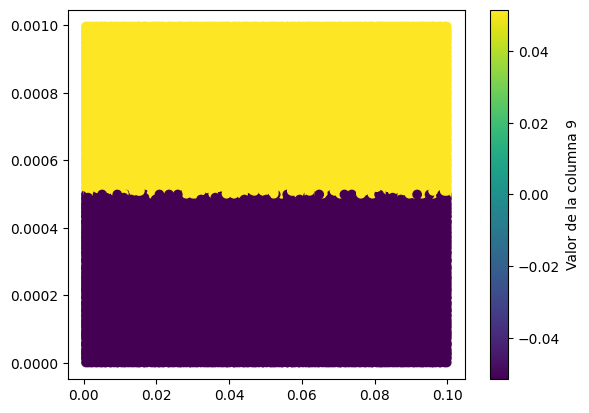

In [17]:
plt.scatter(x_collocation_orig[:, 0], x_collocation_orig[:, 1], c=x_collocation_orig[:, 9])
plt.colorbar(label="Valor de la columna 9")
plt.show()

In [ ]:
# coefficients[:, 0] /= np.abs(coefficients[:, 0])
# coefficients[:, 1] /= np.abs(coefficients[:, 1])
# coefficients[:, 2] /= np.abs(coefficients[:, 2])
# coefficients[:, 3] /= np.abs(coefficients[:, 3])
# coefficients[:, 4] /= np.abs(coefficients[:, 4])
# coefficients[:, 5] /= np.abs(coefficients[:, 5])
# coefficients[:, 6] /= np.abs(coefficients[:, 6])
# coefficients[:, 7] /= np.abs(coefficients[:, 7])

In [18]:
x_collocation, y_collocation = np.split(x_collocation, [1], axis=1)

In [19]:
coefficients[:, 7] = -coefficients[:, 7]

In [20]:
x_collocation = tensorize(x_collocation)
y_collocation = tensorize(y_collocation)
coefficients = tensorize(coefficients)
xy_top = tensorize(xy_top)
xy_bottom = tensorize(xy_bottom)
xy_right = tensorize(xy_right)
xy_left = tensorize(xy_left)

x_collocation = x_collocation.to(device)
y_collocation = y_collocation.to(device)
coefficients = coefficients.to(device)
xy_top = xy_top.to(device)
xy_bottom = xy_bottom.to(device)
xy_right = xy_right.to(device)
xy_left = xy_left.to(device)

xy_left.shape

torch.Size([398, 2])

In [ ]:
x_collocation.shape, y_collocation.shape

In [ ]:
loss_fn = nn.MSELoss()

In [ ]:
force = [0.0, 0]

In [ ]:
def physics_loss(x, y, model):

    x_data = x
    y_data = y
    data = torch.hstack((x_data, y_data))
    y_hat = model(data)

    u_pred = y_hat[:, 0:1]
    v_pred = y_hat[:, 1:2]
    phi_pred = y_hat[:, 2:3]
    sigmax_pred = y_hat[:, 3:4]
    sigmaz_pred = y_hat[:, 4:5]
    tauxz_pred = y_hat[:, 5:6]
    Dx_pred = y_hat[:, 6:7]
    Dy_pred = y_hat[:, 7:8]

    # ux = torch.autograd.grad(outputs=u_pred, inputs=x_data, grad_outputs=torch.ones_like(u_pred), create_graph=True, retain_graph=True)[0]
    # uy = torch.autograd.grad(outputs=u_pred, inputs=y_data, grad_outputs=torch.ones_like(u_pred), create_graph=True, retain_graph=True)[0]

    # vx = torch.autograd.grad(outputs=v_pred, inputs=x_data, grad_outputs=torch.ones_like(v_pred), create_graph=True, retain_graph=True)[0]
    # vy = torch.autograd.grad(outputs=v_pred, inputs=y_data, grad_outputs=torch.ones_like(v_pred), create_graph=True, retain_graph=True)[0]

    # phix = torch.autograd.grad(outputs=phi_pred, inputs=x_data, grad_outputs=torch.ones_like(phi_pred), create_graph=True, retain_graph=True)[0]
    # phiy = torch.autograd.grad(outputs=phi_pred, inputs=y_data, grad_outputs=torch.ones_like(phi_pred), create_graph=True, retain_graph=True)[0]

    # sigmax_pred_x = torch.autograd.grad(outputs=sigmax_pred, inputs=x_data, grad_outputs=torch.ones_like(sigmax_pred), create_graph=True, retain_graph=True)[0]
    # tauxz_pred_y = torch.autograd.grad(outputs=tauxz_pred, inputs=y_data, grad_outputs=torch.ones_like(tauxz_pred), create_graph=True, retain_graph=True)[0]
    # tauxz_pred_x = torch.autograd.grad(outputs=tauxz_pred, inputs=x_data, grad_outputs=torch.ones_like(tauxz_pred), create_graph=True, retain_graph=True)[0]
    # sigmaz_pred_y = torch.autograd.grad(outputs=sigmaz_pred, inputs=y_data, grad_outputs=torch.ones_like(sigmaz_pred), create_graph=True, retain_graph=True)[0]

    # Dx_pred_x = torch.autograd.grad(outputs=Dx_pred, inputs=x_data, grad_outputs=torch.ones_like(Dx_pred), create_graph=True, retain_graph=True)[0]
    # Dy_pred_y = torch.autograd.grad(outputs=Dy_pred, inputs=y_data, grad_outputs=torch.ones_like(Dy_pred), create_graph=True, retain_graph=True)[0]

    all_grads = [torch.autograd.grad(y_hat[:, i].sum(), data, create_graph=True)[0] for i in range(y_hat.shape[1])]

    # Ahora, simplemente extraemos las derivadas que necesitamos.
    # all_grads[0] contiene las derivadas de u_pred (ux, uy)
    ux = all_grads[0][:, 0:1]
    uy = all_grads[0][:, 1:2]

    # all_grads[1] contiene las derivadas de v_pred (vx, vy)
    vx = all_grads[1][:, 0:1]
    vy = all_grads[1][:, 1:2]

    # all_grads[2] contiene las derivadas de phi_pred (phix, phiy)
    phix = all_grads[2][:, 0:1]
    phiy = all_grads[2][:, 1:2]

    # all_grads[3] contiene las derivadas de sigmax_pred
    sigmax_pred_x = all_grads[3][:, 0:1]

    # all_grads[4] contiene las derivadas de sigmaz_pred
    sigmaz_pred_y = all_grads[4][:, 1:2]

    # all_grads[5] contiene las derivadas de tauxz_pred
    tauxz_pred_x = all_grads[5][:, 0:1]
    tauxz_pred_y = all_grads[5][:, 1:2]

    # all_grads[6] contiene las derivadas de Dx_pred
    Dx_pred_x = all_grads[6][:, 0:1]

    # all_grads[7] contiene las derivadas de Dy_pred
    Dy_pred_y = all_grads[7][:, 1:2]


    epsilon_xx = ux
    epsilon_yy = vy
    epsilon_xy = (uy + vx)

    Ex = -phix
    Ey = -phiy

    C11 = coefficients[:, 0:1]
    C12 = coefficients[:, 1:2]
    C22 = coefficients[:, 2:3]
    G = coefficients[:, 3:4]
    epsilon1 = coefficients[:, 4:5]
    epsilon2 = coefficients[:, 5:6]
    e31 = coefficients[:, 6:7]
    e33 = coefficients[:, 7:8]

    e11 = 0
    e13 = 0
    e14 = 0
    e34 = 0

    sigmax = (C11 * epsilon_xx + C12 * epsilon_yy - e31 * Ey)
    sigmaz = (C12 * epsilon_xx + C22 * epsilon_yy - e33 * Ey)
    tauxz = G * epsilon_xy

    Dx = epsilon1 * Ex
    Dy = (e31 * epsilon_xx + e33 * epsilon_yy + epsilon2 * Ey)

    divergence_sigma1 = sigmax_pred_x + tauxz_pred_y
    divergence_sigma2 = tauxz_pred_x + sigmaz_pred_y

    divergence_D = Dx_pred_x + Dy_pred_y

    residual_sigmax = sigmax_pred - sigmax
    residual_sigmaz = sigmaz_pred - sigmaz
    residual_tauxz = tauxz_pred - tauxz

    residual_Dx = Dx_pred - Dx
    residual_Dy = Dy_pred - Dy

    loss_mech = torch.mean(residual_sigmax**2) + \
                        torch.mean(residual_sigmaz**2) + \
                        torch.mean(residual_tauxz**2)

    loss_elec = torch.mean(residual_Dx**2) + torch.mean(residual_Dy**2)

    loss_divergence = torch.mean((divergence_sigma1)**2) + \
                        torch.mean((divergence_sigma2)**2) + \
                        torch.mean((divergence_D)**2)


    # # Pesos adaptativos para balancear
    # w_mech = 1.0 / (loss_mech.detach() + 1e-15)
    # w_elec = 1.0 / (loss_elec.detach() + 1e-15)
    # w_div = 1.0 / (loss_divergence.detach() + 1e-15)

    # Normalizar pesos
    # w_sum = w_mech + w_elec + w_div
    w_mech = 1#w_mech / w_sum
    w_elec = 1#loss_mech
    w_div = 1#w_div / w_sum

    return w_mech * loss_mech + w_elec * loss_elec + w_div * loss_divergence, residual_sigmax, residual_sigmaz, residual_tauxz, residual_Dx, residual_Dy, divergence_sigma1, divergence_sigma2, divergence_D


    # return loss_mech + loss_elec + loss_divergence

In [ ]:
torch.set_printoptions(profile="default")
coefficients

In [ ]:
def traction_BC_loss(xy_right, model, applied_force_y):
    """
    Aplica una fuerza de 1N distribuida sobre el área del extremo derecho
    Área = HEIGHT = 0.001 m
    Tracción = Force / Area = 1 N / 0.001 m = 1000 N/m
    """
    y_hat_right = model(xy_right)

    sigmax_pred_right = y_hat_right[:, 3:4]
    sigmaz_pred_right = y_hat_right[:, 4:5]
    tauxz_pred_right = y_hat_right[:, 5:6]

    # Normal vector apunta hacia -y
    n_x = 1.0
    n_y = 0.0

    # Tracción aplicada: t = σ·n
    # Queremos: t_x = 0, t_y = Force
    traction_x = sigmax_pred_right * n_x + tauxz_pred_right * n_y
    traction_y = tauxz_pred_right * n_x + sigmaz_pred_right * n_y

    # Tracción objetivo
    area = HEIGHT # en metros
    target_traction_y = applied_force_y / HEIGHT

    loss_traction_x = torch.mean(traction_x**2)
    loss_traction_y = torch.mean((traction_y - target_traction_y)**2)

    return loss_traction_x + loss_traction_y

In [1]:
def stress_BC_loss(xy_top, xy_bottom, xy_right, xy_left, model):
    y_hat_top = model(xy_top)
    y_hat_bottom = model(xy_bottom)

    sigmax_pred_top = y_hat_top[:, 3:4]
    tauxz_pred_top = y_hat_top[:, 5:6]

    sigmax_pred_bottom = y_hat_bottom[:, 3:4]
    tauxz_pred_bottom = y_hat_bottom[:, 5:6]

    # Traction free en top y bottom
    loss_top = torch.mean(sigmax_pred_top**2) + torch.mean(tauxz_pred_top**2)
    loss_bottom = torch.mean(sigmax_pred_bottom**2) + torch.mean(tauxz_pred_bottom**2)

    # Left end sigue clamped (ya está en hard constraint de u, v)
    # Right end tiene tracción aplicada
    loss_right = traction_BC_loss(xy_right, model, applied_force_y=0.1)

    return loss_top + loss_right + loss_bottom
    #return loss_right

In [2]:
def electric_BC_loss(xy_right, xy_left, xy_top, model):
  y_hat_right = model(xy_right)
  y_hat_left = model(xy_left)
  y_hat_top = model(xy_top)

  Dx_pred_right = y_hat_right[:, 6:7]
  Dy_pred_right = y_hat_right[:, 7:8]

  Dx_pred_left = y_hat_left[:, 6:7]
  Dy_pred_left = y_hat_left[:, 7:8]

  Dx_pred_top = y_hat_top[:, 6:7]
  Dy_pred_top = y_hat_top[:, 7:8]

  n_right = torch.ones_like(xy_right)
  n_right[:, 1] = 0

  n_left = torch.ones_like(xy_left)
  n_left[:, 0] = -1
  n_left[:, 1] = 0

  n_top = torch.ones_like(xy_top)
  n_top[:, 0] = 0
  n_top[:, 1] = 1

  D_dot_n_right = Dx_pred_right * n_right[:, 0:1] + Dy_pred_right * n_right[:, 1:2]
  D_dot_n_left = Dx_pred_left * n_left[:, 0:1] + Dy_pred_left * n_left[:, 1:2]
  D_dot_n_top = Dx_pred_top * n_top[:, 0:1] + Dy_pred_top * n_top[:, 1:2]

  loss_right = torch.mean(D_dot_n_right**2)
  loss_left = torch.mean(D_dot_n_left**2)
  loss_top = torch.mean(D_dot_n_top**2)

  return loss_right + loss_left + loss_top

In [3]:
def electric_potential_BC_loss(xy_bottom):
  y_hat_bottom = model(xy_bottom)
  potential_pred = y_hat_bottom[:, 2:3]

  return torch.mean(potential_pred**2)

In [4]:
def displacement_BC_loss(xy_left):
  y_hat_left = model(xy_left)
  u = y_hat_left[:, 0:1]
  v = y_hat_left[:, 1:2]

  return torch.mean((u)**2) + torch.mean((v)**2)

In [5]:
def update_weights(pde_loss, bc_loss, weights):
  lambda_1 = weights['pde']
  lambda_2 = weights['bc']

  # --- CORRECTED GRADIENT NORM CALCULATION ---
  # Get all gradients for the PDE loss
  all_grad_pde = torch.autograd.grad(pde_loss, model.parameters(), retain_graph=True, allow_unused=True)
  # Concatenate all gradient tensors into a single vector and compute the norm
  grad_pde_vec = torch.cat([grad.view(-1) for grad in all_grad_pde if grad is not None])
  norm_pde = torch.linalg.norm(grad_pde_vec)

  # Get all gradients for the BC loss
  all_grad_bc = torch.autograd.grad(bc_loss, model.parameters(), retain_graph=True, allow_unused=True)
  # Concatenate all gradient tensors into a single vector and compute the norm
  grad_bc_vec = torch.cat([grad.view(-1) for grad in all_grad_bc if grad is not None])
  norm_bc = torch.linalg.norm(grad_bc_vec)
  # --- END OF CORRECTION ---

  gradients = norm_pde + norm_bc

  # Add a small epsilon to prevent division by zero
  lambda_1_hat = gradients / (norm_pde + 1e-12)
  lambda_2_hat = gradients / (norm_bc + 1e-12)

  # Use an exponential moving average to stabilize the weights
  alpha = 0.9
  lambda_1 = alpha * lambda_1 + (1 - alpha) * lambda_1_hat
  lambda_2 = alpha * lambda_2 + (1 - alpha) * lambda_2_hat

  # No need to empty cache here, PyTorch handles it well
  # torch.cuda.empty_cache()

  return {'pde': lambda_1, 'bc': lambda_2}

In [6]:
def get_BC_loss(xy_top, xy_bottom, xy_right, xy_left):
    stress_loss_term = stress_BC_loss(xy_top, xy_bottom, xy_right, xy_left, model)
    electric_loss_term = electric_BC_loss(xy_right, xy_left, xy_top, model)

    return stress_loss_term + electric_loss_term, stress_loss_term, electric_loss_term #+ 10e3 * elec_potential_loss_term #+ 10e12 * displacement_loss_term

In [7]:
def loss_func(xy_top, xy_bottom, xy_right, xy_left, x_collocation, y_collocation,
              model, loss_weights, n, f, only_BCs=False, adjust=False):
    """
    Función de pérdida con monitoreo de residuos usando las mismas escalas
    """
    BC_term, stress_loss_term, electric_loss_term = get_BC_loss(xy_top, xy_bottom, xy_right, xy_left)
    physics_loss_term, residual_sigmax, residual_sigmaz, residual_tauxz, residual_Dx, residual_Dy, \
          divergence_sigma1, divergence_sigma2, divergence_D = physics_loss(x_collocation, y_collocation, model)

    if only_BCs:
      physics_loss_term = 0



    if n % f == 0 and adjust:
      # print('cambio', n, f)
      loss_weights = update_weights(physics_loss_term, BC_term, loss_weights)

    lambda1 = loss_weights['bc']
    lambda3 = loss_weights['pde']

    loss = lambda1 * BC_term + lambda3 * physics_loss_term
    return loss, loss_weights

In [8]:
epochs_ADAM = 3000
epochs_LBFGS = 0
total_epochs = 1 * (epochs_ADAM + epochs_LBFGS)

In [9]:
optimizer_ADAM = torch.optim.Adam(params=model.parameters(), lr=0.005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer_ADAM, step_size=5000, gamma=0.95)

NameError: name 'torch' is not defined

In [ ]:
# mlflow.start_run()
# mlflow.log_param("epochs_ADAM", epochs_ADAM)
# mlflow.log_param("epochs_LBFGS", epochs_LBFGS)
# mlflow.log_param("learning_rate_ADAM", optimizer_ADAM.state_dict()['param_groups'][0]['lr'])
# mlflow.log_param("learning_rate_LBFGS", optimizer_LBFGS.state_dict()['param_groups'][0]['lr'])

In [ ]:
loss_list = []

In [ ]:
loss_weights = {'pde': 1, 'bc': 1}

In [ ]:
f = 200

In [ ]:
checkpoints_ADAM = root + 'checkpoints_ADAM/'
best_loss_ADAM = float('inf')

In [ ]:
start_time = time.time()

In [ ]:
for epoch in range(epochs_ADAM):
    optimizer_ADAM.zero_grad()
    loss, loss_weights = loss_func(xy_top, xy_bottom, xy_right, xy_left, x_collocation, y_collocation, model, loss_weights, epoch, f)
    loss.backward()
    optimizer_ADAM.step()
    loss_list.append(loss.item())
    #scheduler.step()

    if epoch % 100 == 0:
        print(f"Epoch: {epoch}/{total_epochs}. Loss: {loss.item()}.")
        print(optimizer_ADAM.state_dict()['param_groups'][0]['lr'])
        #mlflow.log_metric("loss_ADAM", loss.item(), step=epoch)

        # Guardar el modelo si la pérdida es  la mejor hasta el momento
        # if loss.item() < best_loss_ADAM:
        #     best_loss_ADAM = loss.item()
        #     checkpoint_path = os.path.join(checkpoints_ADAM, f"model_epoch_{epoch}_loss_{best_loss_ADAM:.4f}.pt")
        #     torch.save({
        #         'epoch': epoch,
        #         'model_state_dict': model.state_dict(),
        #         'optimizer_state_dict': optimizer_ADAM.state_dict(),
        #         'loss': loss.item(),
        #         'loss_weights': loss_weights,
        #     }, checkpoint_path)
        #     print(f"Checkpoint saved at epoch {epoch} with loss {best_loss_ADAM:.4f}")

    if epoch % f == 0:
      print(f"Lambda_1: {loss_weights}.")

In [ ]:
# for epoch in range(epochs_ADAM):
#     optimizer_ADAM.zero_grad()
#     loss, loss_weights = loss_func(xy_top, xy_bottom, xy_right, xy_left, x_collocation, y_collocation, model, loss_weights, epoch, f)
#     loss.backward()
#     optimizer_ADAM.step()
#     loss_list.append(loss.item())
#     #scheduler.step()

#     if epoch % 100 == 0:
#         print(f"Epoch: {epoch}/{total_epochs}. Loss: {loss.item()}.")
#         print(optimizer_ADAM.state_dict()['param_groups'][0]['lr'])
#         # mlflow.log_metric("loss_ADAM", loss.item(), step=epoch)

#         # Guardar el modelo si la pérdida es  la mejor hasta el momento
#         # if loss.item() < best_loss_ADAM:
#         #     best_loss_ADAM = loss.item()
#         #     checkpoint_path = os.path.join(checkpoints_ADAM, f"model_epoch_{epoch}_loss_{best_loss_ADAM:.4f}.pt")
#         #     torch.save({
#         #         'epoch': epoch,
#         #         'model_state_dict': model.state_dict(),
#         #         'optimizer_state_dict': optimizer_ADAM.state_dict(),
#         #         'loss': loss.item(),
#         #         'loss_weights': loss_weights,
#         #     }, checkpoint_path)
#         #     print(f"Checkpoint saved at epoch {epoch} with loss {best_loss_ADAM:.4f}")

#     if epoch % f == 0:
#       print(f"Lambda_1: {loss_weights}.")

In [ ]:
loss_weights

In [ ]:
checkpoints_dir = root + 'checkpoints_LBFGS2/'
best_loss = float('inf')

In [ ]:
optimizer_LBFGS = torch.optim.LBFGS(params=model.parameters(), lr=0.0001)

In [ ]:
from math import nan
for epoch in range(epochs_LBFGS):
    def closure():
        global loss_weights, epoch, f
        # Limpiar los gradientes antes de calcular la pérdida
        optimizer_LBFGS.zero_grad()
        # Calcular la pérdida
        loss, loss_weights = loss_func(xy_top, xy_bottom, xy_right, xy_left, x_collocation, y_collocation, model, loss_weights, epoch, f)
        # Realizar el paso hacia atrás
        loss.backward()
        # Retornar la pérdida para que LBFGS pueda usarla
        return loss

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

    optimizer_LBFGS.step(closure)

    loss = closure()

    loss_list.append(loss.item())

    if loss.item() == nan:
      print('nan')
      break

    if epoch % 100 == 0 or epoch == epochs_LBFGS - 1:
        print(f"Epoch: {epochs_ADAM + epoch}/{total_epochs}. Loss: {loss.item()}.")
        # mlflow.log_metric("loss_LBFGS", loss.item(), step=epochs_ADAM + epoch)

    # Guardar el modelo si la pérdida es la mejor hasta el momento
    # if loss.item() < best_loss:l
    #     best_loss = loss.item()
    #     checkpoint_path = os.path.join(checkpoints_dir, f"model_epoch_{epoch}_loss_{best_loss:.4f}.pt")
    #     torch.save({
    #         'epoch': epoch,
    #         'model_state_dict': model.state_dict(),
    #         'optimizer_state_dict': optimizer_LBFGS.state_dict(),
    #         'loss': loss.item(),
    #         'loss_weights': loss_weights,
    #     }, checkpoint_path)
    #     print(f"Checkpoint saved at epoch {epoch} with loss {best_loss:.4f}")

In [10]:
end_time = time.time()

NameError: name 'time' is not defined

In [ ]:
total_time = end_time - start_time
print(total_time)
print(total_time / 60)

# mlflow.log_metric("total_training_time_seconds", total_time)

In [ ]:
# mlflow.log_param("final_loss", best_loss)
# mlflow.log_metric("final_epoch", epoch)

In [28]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300,
})

# Asegúrate de que loss_list esté en np.array
loss_array = np.array(loss_list)
log_loss = np.log(loss_array)

# Crear figura
plt.figure(figsize=(6, 4))
plt.plot(log_loss, color='navy', linewidth=2)

# Etiquetas y título en inglés
plt.xlabel('Epochs')
plt.ylabel('Training Loss (log scale)')
plt.title('Training Loss Curve')

# Mejorar el grid
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Bordes y layout ajustado
plt.tight_layout()

# Guardar y registrar en MLflow
# with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmpfile:
#     plt.savefig(tmpfile.name, format='png', dpi=300, bbox_inches='tight')
#     mlflow.log_artifact(tmpfile.name, artifact_path="plots")

plt.show()

NameError: name 'loss_list' is not defined

In [27]:
x_test = np.load(root + 'x_collocation_test_non_normalized_m1_d.npy')
x_test = x_test[:, :2]
# x_test[:, 0:1], x_test[:, 1:2] = x_test[:, 0:1] / WIDTH, x_test[:, 1:2] / HEIGHT
x_test = tensorize(x_test)
x_test.shape

torch.Size([40000, 2])

In [ ]:
# Save model
# path_model_paper = root + 'models_PINN/'
# torch.save(model.state_dict(), path_model_paper + 'model_PINN_direct_paper_3.pt')

In [24]:
# state = checkpoints_dir + 'model_epoch_100_loss_46466896.0000.pt'
state = root + 'models_PINN/' + 'model_PINN_direct_paper_3.pt'
state_dict = torch.load(state)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [29]:
preds = model(x_test).detach().cpu().numpy()
u_pred = preds[:, 0]
v_pred = preds[:, 1]
phi_pred = preds[:, 2]
sigmax_pred = preds[:, 3]
sigmaz_pred = preds[:, 4]
tauxz_pred = preds[:, 5]
Dx_pred = preds[:, 6]
Dy_pred = preds[:, 7]

In [30]:
# x_test = x_electrical_bc.detach().cpu().numpy()
x_test = x_test.detach().cpu().numpy()
# x_test[:, 0:1], x_test[:, 1:2] = x_test[:, 0:1] * WIDTH, x_test[:, 1:2] * HEIGHT

In [31]:
def plot_results(x, y, value, title, filename, xlabel='x', ylabel='y', colorbar_label='Value', save=False):
    fig = plt.figure(figsize=(7, 2))  # Mismo tamaño que antes
    ax = fig.add_subplot(111)

    # Ajustes para estilo académico sin afectar tamaño visual
    ax.set_title(title, fontsize=11, fontfamily='serif')
    ax.set_xlabel(xlabel, fontsize=10, fontfamily='serif')
    ax.set_ylabel(ylabel, fontsize=10, fontfamily='serif')

    scatter = ax.scatter(x, y, c=value, cmap='jet', s=30, edgecolors='none')

    ax.tick_params(axis='both', which='major', labelsize=8, direction='in', length=4, width=0.8)
    ax.spines['top'].set_linewidth(0.8)
    ax.spines['right'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.spines['left'].set_linewidth(0.8)

    # Barra de colores
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label(colorbar_label, fontsize=10, fontfamily='serif')
    cbar.ax.tick_params(labelsize=8)

    if save:
        with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmpfile:
            fig.savefig(tmpfile.name, format='png', dpi=300, bbox_inches='tight')
            print(f"Graph temporarily saved at {tmpfile.name}")
            mlflow.log_artifact(tmpfile.name, artifact_path="plots")
            print(f"Graph logged to MLflow as artifact {filename}")

    plt.show()

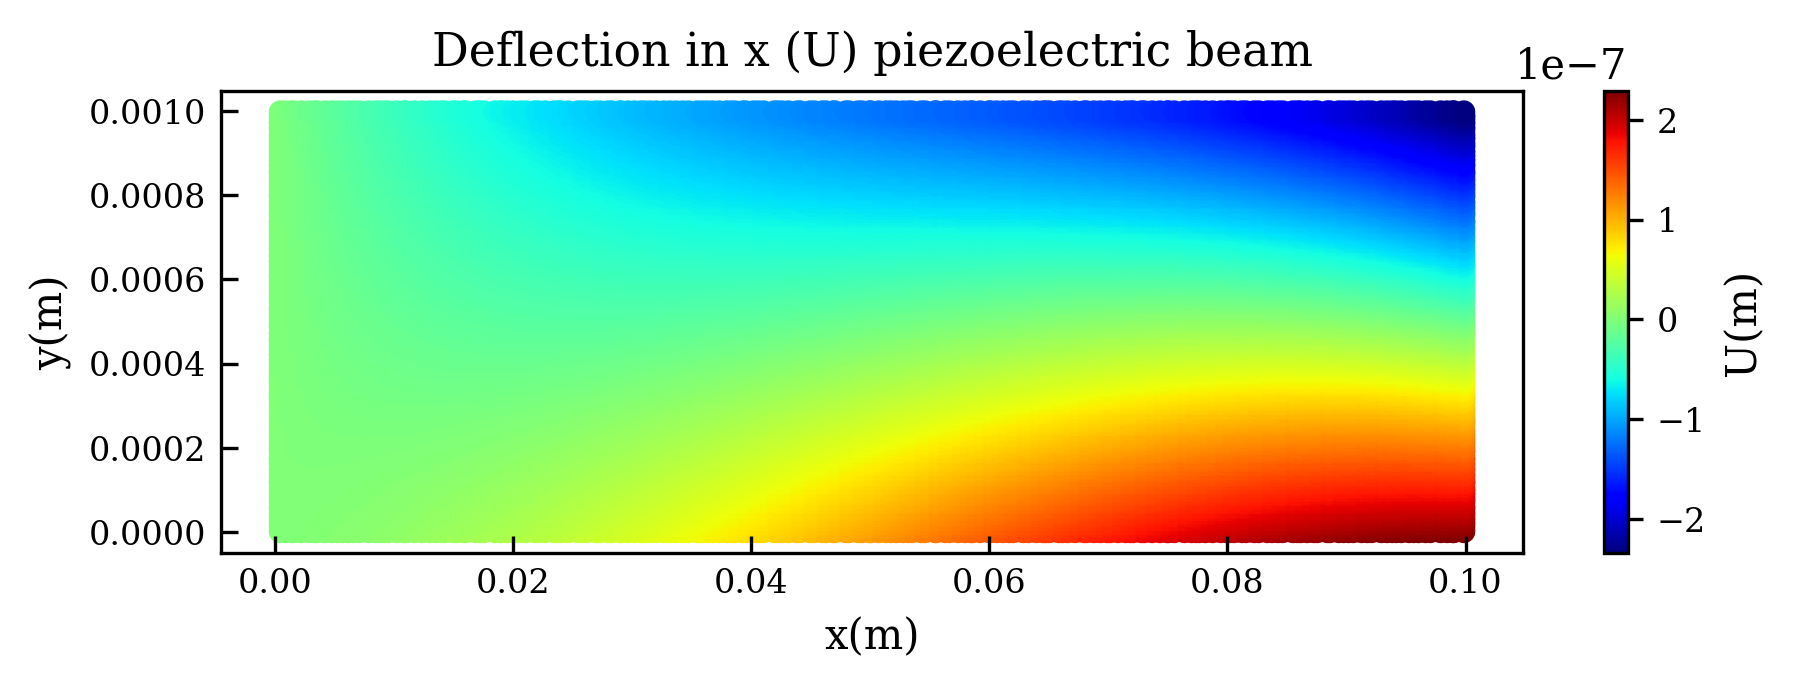

In [32]:
filename = "u_displacement_plot.png"
plot_results(x_test[:, 0], x_test[:, 1], u_pred,
             title='Deflection in x (U) piezoelectric beam',
             filename=filename,
             xlabel='x(m)',
             ylabel='y(m)',
             colorbar_label='U(m)')

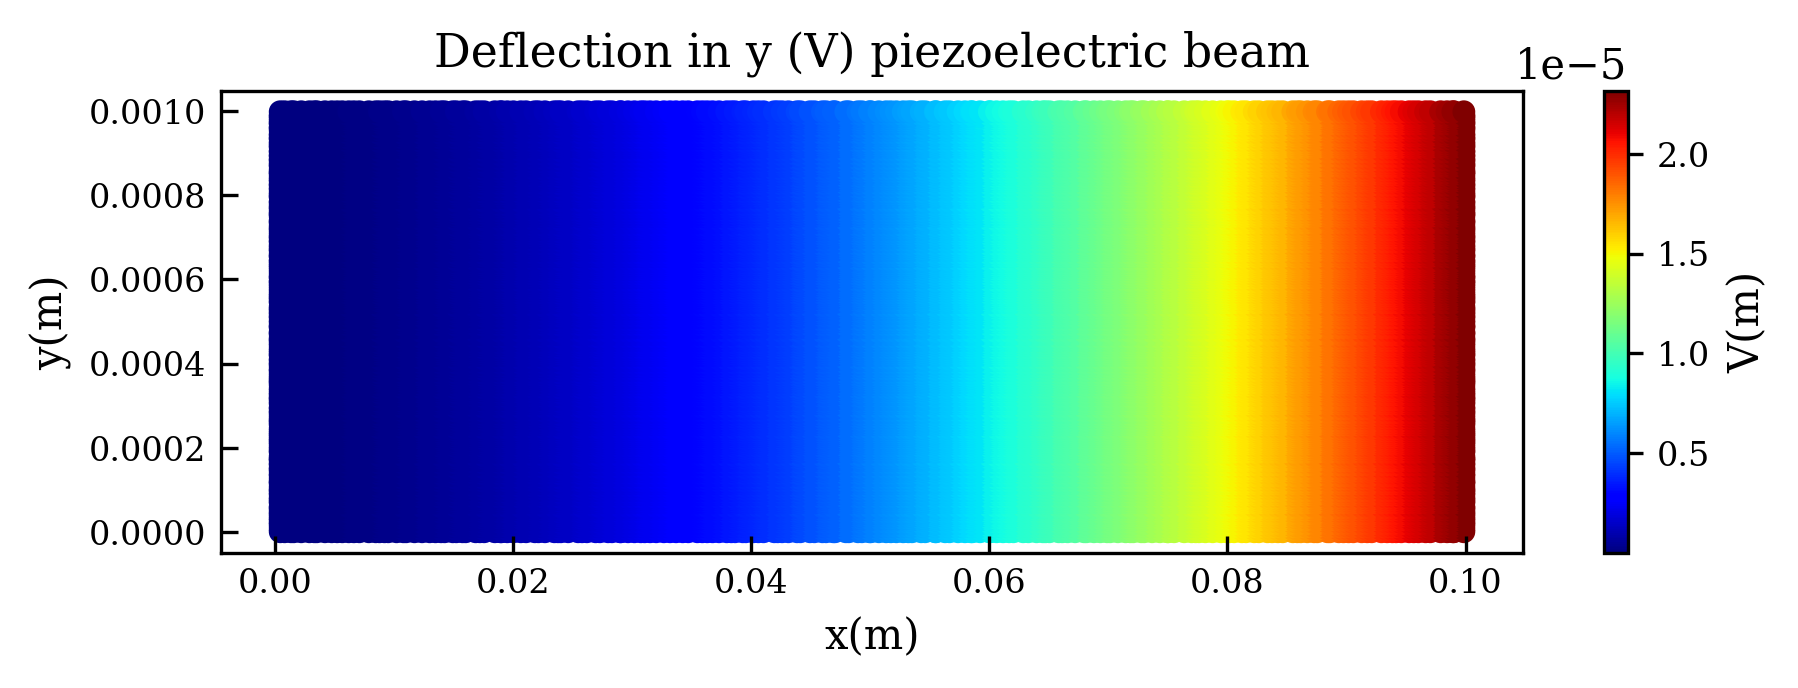

In [33]:
filename = "v_displacement_plot.png"
plot_results(x_test[:, 0], x_test[:, 1], v_pred,
             title='Deflection in y (V) piezoelectric beam',
             filename=filename,
             xlabel='x(m)',
             ylabel='y(m)',
             colorbar_label='V(m)')

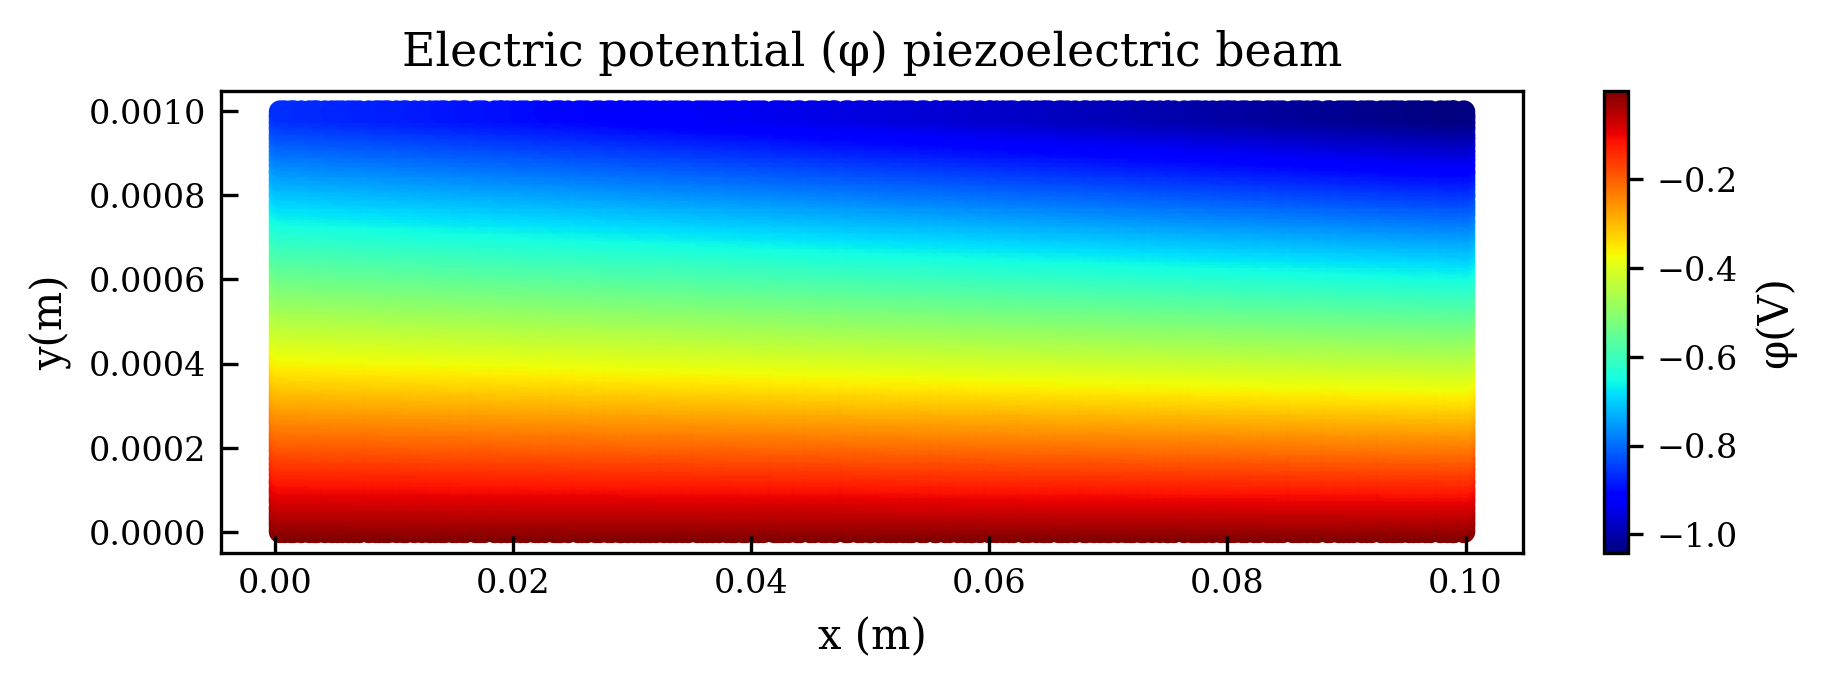

In [34]:
filename = "phi_plot.png"
plot_results(x_test[:, 0], x_test[:, 1], phi_pred,
             title='Electric potential (φ) piezoelectric beam',
             filename=filename,
             xlabel='x (m)',
             ylabel='y(m)',
             colorbar_label='φ(V)')

In [ ]:
# torch.save(model.state_dict(), root + 'models_PINN/model_PINN_9.pt')

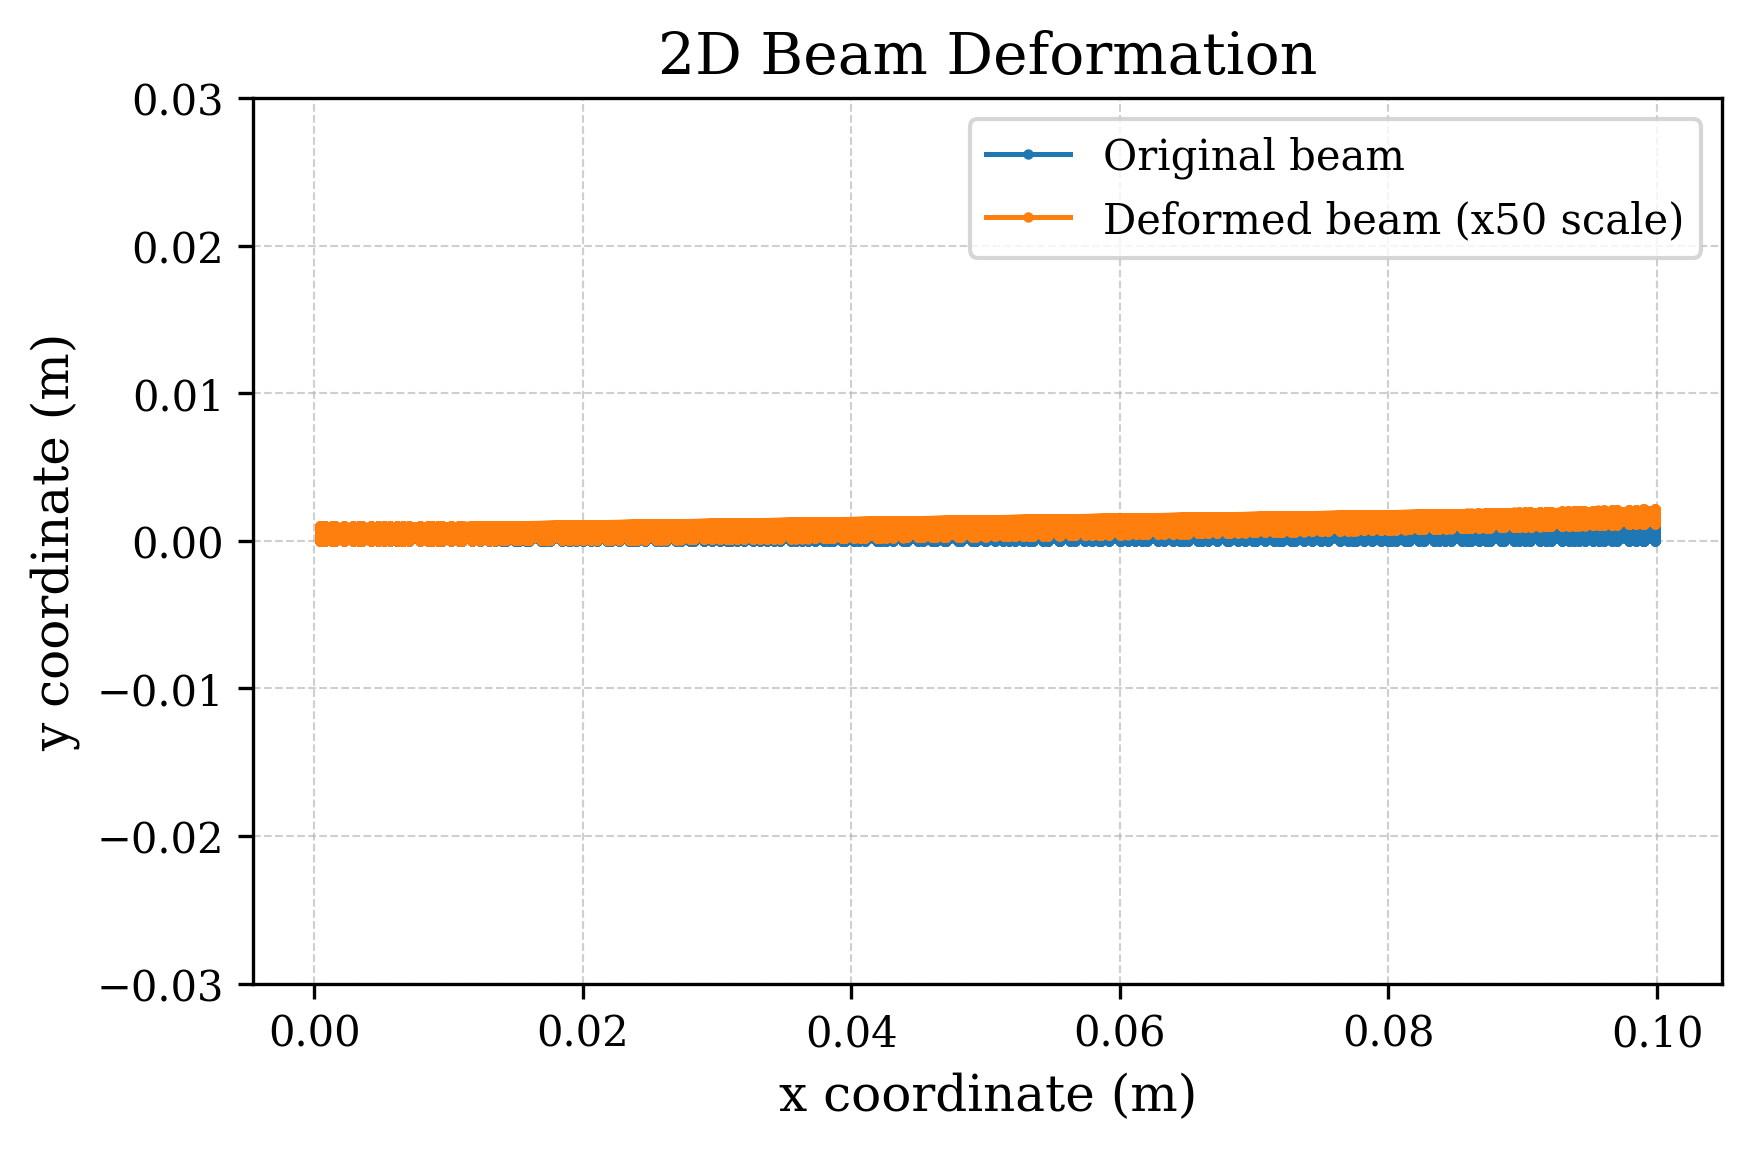

In [36]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 300,
})

scale_factor = 50  # Factor de amplificación de deformación

# Coordenadas
x_coords = x_test[:, 0]
y_coords = x_test[:, 1]
x_deformed = x_coords + scale_factor * u_pred
y_deformed = y_coords + scale_factor * v_pred

# Crear figura
plt.figure(figsize=(6, 4))

# Nuevos colores
original_color = "#1f77b4"   # azul oscuro
deformed_color = "#ff7f0e"   # naranja suave

# Curva original
plt.plot(x_coords, y_coords, color=original_color, linestyle='-', linewidth=1.2,
         marker='o', markersize=1.5, label='Original beam')

# Curva deformada
plt.plot(x_deformed, y_deformed, color=deformed_color, linestyle='-', linewidth=1.2,
         marker='o', markersize=1.5, label=f'Deformed beam (x{scale_factor} scale)')

# Limitar eje Y
plt.ylim(-0.03, 0.03)

# Estilo de la gráfica
plt.title('2D Beam Deformation')
plt.xlabel('x coordinate (m)')
plt.ylabel('y coordinate (m)')
plt.legend(loc='best')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()

# Exportación opcional a MLflow o archivo
# import tempfile, mlflow
# with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmpfile:
#     plt.savefig(tmpfile.name, format='png', dpi=300, bbox_inches='tight')
#     mlflow.log_artifact(tmpfile.name, artifact_path="plots")

# Mostrar
plt.show()

In [ ]:
# plot_results(x_test[:, 0], x_test[:, 1], sigmax_pred, 'sigmax')

In [ ]:
# plot_results(x_test[:, 0], x_test[:, 1], sigmaz_pred, 'sigmaz')

In [ ]:
# plot_results(x_test[:, 0], x_test[:, 1], tauxz_pred, 'tauxz')

In [ ]:
# plot_results(x_test[:, 0], x_test[:, 1], Dx_pred, 'Dx')

In [ ]:
# plot_results(x_test[:, 0], x_test[:, 1], Dy_pred, 'Dy')

In [ ]:
ground_truth = pd.read_csv(root + 'FEM.csv')
X_ground_truth = ground_truth['X_Coordinate'].values
Y_ground_truth = ground_truth['Y_Coordinate'].values
U = ground_truth['X_Deflection'].values
V = ground_truth['Y_Deflection'].values
Phi_ground_truth = ground_truth['Potential'].values

In [ ]:
X_ground_truth = X_ground_truth.reshape(-1, 1)
Y_ground_truth = Y_ground_truth.reshape(-1, 1)

In [ ]:
X_ground_truth = np.hstack((X_ground_truth, Y_ground_truth))
X_ground_truth_tensor = tensorize(X_ground_truth)

In [ ]:
preds_gr = model(X_ground_truth_tensor).detach().cpu().numpy()
u_pred_gr = preds_gr[:, 0]
v_pred_gr = preds_gr[:, 1]
phi_pred_gr = preds_gr[:, 2]

In [ ]:
U = np.array(U)
V = np.array(V)
Phi_ground_truth = np.array(Phi_ground_truth)

# Relative L2 error
l2_u = np.linalg.norm(u_pred_gr - U) / np.linalg.norm(U)
l2_v = np.linalg.norm(v_pred_gr - V) / np.linalg.norm(V)
l2_phi = np.linalg.norm(phi_pred_gr - Phi_ground_truth) / np.linalg.norm(Phi_ground_truth)

print(f"Relative L2 error (u): {l2_u:.4e}")
print(f"Relative L2 error (v): {l2_v:.4e}")
print(f"Relative L2 error (phi): {l2_phi:.4e}")

In [ ]:
l2_norm_u = np.linalg.norm(U - u_pred_gr)
l2_norm_v = np.linalg.norm(V - v_pred_gr)
l2_norm_phi = np.linalg.norm(Phi_ground_truth - phi_pred_gr)

print("L2 Norm for U:", l2_norm_u)
print("L2 Norm for V:", l2_norm_v)
print("L2 Norm for Phi:", l2_norm_phi)

In [ ]:
# mlflow.log_metric("L2_Norm_U", l2_norm_u)
# mlflow.log_metric("L2_Norm_V", l2_norm_v)
# mlflow.log_metric("L2_Norm_Phi", l2_norm_phi)

In [ ]:
filename = "u_displacement_plot.png"
plot_results(X_ground_truth[:, 0], X_ground_truth[:, 1], U,
             title='Desplazamiento Horizontal U FEM',
             filename=filename,
             xlabel='Posición x (metros)',
             ylabel='Posición y (metros)',
             colorbar_label='Desplazamiento horizontal (metros)')

In [ ]:
filename = "u_displacement_plot.png"
plot_results(X_ground_truth[:, 0], X_ground_truth[:, 1], V,
             title='Desplazamiento Vertical V FEM',
             filename=filename,
             xlabel='Posición x (metros)',
             ylabel='Posición y (metros)',
             colorbar_label='Desplazamiento vertical (metros)')

In [ ]:
plot_results(X_ground_truth[:, 0], X_ground_truth[:, 1], Phi_ground_truth,
             title='Potencial Eléctrico FEM',
             filename=filename,
             xlabel='Posición x (metros)',
             ylabel='Posición y (metros)',
             colorbar_label='Potencial Eléctrico (voltios)')

In [ ]:
scale_factor = 50  # Ajusta este valor según sea necesario

# Extraer coordenadas iniciales
x_coords = X_ground_truth[:, 0]
y_coords = X_ground_truth[:, 1]

# Coordenadas deformadas con escala aplicada
x_deformed = x_coords + scale_factor * U
y_deformed = y_coords + scale_factor * V

# Graficar la viga original y la deformada
plt.figure(figsize=(10, 6))

# Plot de la viga original
plt.plot(x_coords, y_coords, color='steelblue', marker='o', linestyle='-', label='Viga original', markersize=2)

# Plot de la viga deformada
plt.plot(x_deformed, y_deformed, color='darkorange', marker='o', linestyle='-', label='Viga deformada (Escala x{})'.format(scale_factor), markersize=2)

# Configuración del gráfico
plt.title('Deformación del Beam en 2D FEM')
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.legend()
plt.grid(True)
plt.axis('equal')  # Escala igual para evitar distorsión

# with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmpfile:
#     # Guardar el gráfico en el archivo temporal
#     plt.savefig(tmpfile.name, format='png', dpi=300)
#     print(f"Graph temporarily saved at {tmpfile.name}")

#     # Registra el gráfico en MLflow como un artefacto
#     mlflow.log_artifact(tmpfile.name, artifact_path="plots")
#     print(f"Graph logged to MLflow as artifact.")

# Mostrar el gráfico
plt.show()

In [ ]:
def relative_l2_error(u_pred, u_ref):
    return np.linalg.norm(u_pred - u_ref, 2) / np.linalg.norm(u_ref, 2)

In [ ]:
u_relative_error = relative_l2_error(u_pred_gr, U)
v_relative_error = relative_l2_error(v_pred_gr, V)
phi_relative_error = relative_l2_error(phi_pred_gr, Phi_ground_truth)

In [ ]:
u_error = np.abs(U - u_pred_gr)
v_error = np.abs(V - v_pred_gr)
phi_error = np.abs(Phi_ground_truth - phi_pred_gr)

In [ ]:
# Graficar el error absoluto para U
plot_results(X_ground_truth[:, 0], X_ground_truth[:, 1], u_error,
             title='Error Absoluto en Desplazamiento U',
             filename='u_error_plot.png',
             xlabel='Posición x (metros)',
             ylabel='Posición y (metros)',
             colorbar_label='Error Absoluto')

In [ ]:
# Graficar el error absoluto para U
plot_results(X_ground_truth[:, 0], X_ground_truth[:, 1], v_error,
             title='Error Absoluto en Desplazamiento V',
             filename='v_error_plot.png',
             xlabel='Posición x (metros)',
             ylabel='Posición y (metros)',
             colorbar_label='Error Absoluto')

In [ ]:
# Graficar el error absoluto para U
plot_results(X_ground_truth[:, 0], X_ground_truth[:, 1], phi_error,
             title='Error Absoluto en Potencial Eléctrico',
             filename='phi_error_plot.png',
             xlabel='Posición x (metros)',
             ylabel='Posición y (metros)',
             colorbar_label='Error Absoluto')

In [ ]:
print("Relative L2 Error for U:", u_relative_error)
print("Relative L2 Error for V:", v_relative_error)
print("Relative L2 Error for Phi:", phi_relative_error)

In [ ]:
# mlflow.log_metric("u_relative_L2_error", u_relative_error)
# mlflow.log_metric("v_relative_L2_error", v_relative_error)
# mlflow.log_metric("phi_relative_L2_error", phi_relative_error)

In [ ]:
current_seed = torch.initial_seed()

print(f"Semilla actual: {current_seed}")

In [ ]:
# mlflow.log_param("seed", current_seed)

In [ ]:
# mlflow.end_run()